# In Class May 19

In [1]:
# importing libraries
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

### Importing the data

In [2]:
# importing mnist data from keras
(X_train, y_train), (X_test, y_test) = keras.datasets.mnist.load_data()

print("Training data shape:", X_train.shape)
print("Test data shape:", X_test.shape)

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
Training data shape: (60000, 28, 28)
Test data shape: (10000, 28, 28)


### Visualizing the data

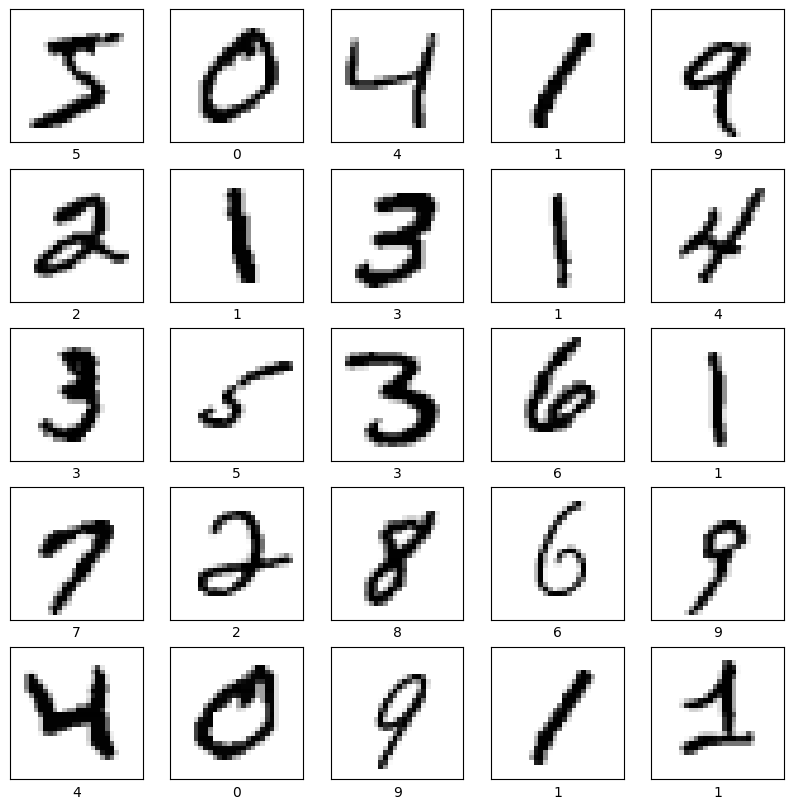

In [3]:
# visualize some of the data
import matplotlib.pyplot as plt
plt.figure(figsize=(10, 10))
for i in range(25):
    plt.subplot(5, 5, i + 1)
    plt.xticks([])
    plt.yticks([])
    plt.grid(False)
    plt.imshow(X_train[i], cmap=plt.cm.binary)
    plt.xlabel(y_train[i])
plt.show()

### Preprocessing data for MLP

In [4]:
# Normalize pixel values to 0–1
X_train_norm = X_train / 255.0   # scale pixel values from 0–255 → 0–1
X_test_norm = X_test / 255.0     # apply same scaling to test data

# Flatten images for the MLP
X_train_flat = X_train_norm.reshape(X_train.shape[0], -1)  # # reshape from (60000, 28, 28) → (60000, 784)
X_test_flat = X_test_norm.reshape(X_test.shape[0], -1)     # same transformation for test images

print(X_train_flat.shape)
print(X_test_flat.shape)

(60000, 784)
(10000, 784)


### Building the MLP model

In [5]:
# Define the MLP model
mlp_model = keras.Sequential([
    layers.Input(shape=(784,)),                 # input is a flattened image (784 pixels)
    layers.Dense(128, activation="relu"),       # hidden layer with 128 neurons (learns patterns)
    layers.Dense(64, activation="relu"),        # second hidden layer for more complex patterns
    layers.Dense(10, activation="softmax"),     # output layer (10 classes for digits 0–9)
])

# Compile the MLP model
mlp_model.compile(
    optimizer="adam",                           # optimization algorithm for training
    loss="sparse_categorical_crossentropy",     # loss for multi-class classification with integer labels
    metrics=["accuracy"]                        # track accuracy during training
)

# summary of the MLP model architecture
mlp_model.summary()

Model: "sequential"
┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┳━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape  ┃ Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━╇━━━━━━━━━┩
│ dense (Dense)       │ (None, 128)   │ 100,480 │
├─────────────────────┼───────────────┼─────────┤
│ dense_1 (Dense)     │ (None, 64)    │   8,256 │
├─────────────────────┼───────────────┼─────────┤
│ dense_2 (Dense)     │ (None, 10)    │     650 │
└─────────────────────┴───────────────┴─────────┘
 Total params: 109,386 (427.29 KB)
 Trainable params: 109,386 (427.29 KB)
 Non-trainable params: 0 (0.00 B)


In [6]:
# train the MLP model
history_mlp = mlp_model.fit(
    X_train_flat,                               # flattened training images
    y_train,                                    # labels (0–9)
    epochs=5,                                   # number of training passes through data
    batch_size=128,                             # number of samples per training step
    validation_split=0.1                        # use 10% of training data for validation
)

# evaluate the MLP model on test data
test_loss_mlp, test_acc_mlp = mlp_model.evaluate(X_test_flat, y_test, verbose=2)
print(f"MLP Test accuracy: {test_acc_mlp:.4f}")

Epoch 1/5
422/422 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.9002 - loss: 0.3613 - val_accuracy: 0.9610 - val_loss: 0.1399
Epoch 2/5
422/422 ━━━━━━━━━━━━━━━━━━━━ 0s 889us/step - accuracy: 0.9579 - loss: 0.1448 - val_accuracy: 0.9690 - val_loss: 0.1078
Epoch 3/5
422/422 ━━━━━━━━━━━━━━━━━━━━ 0s 891us/step - accuracy: 0.9701 - loss: 0.1005 - val_accuracy: 0.9753 - val_loss: 0.0869
Epoch 4/5
422/422 ━━━━━━━━━━━━━━━━━━━━ 0s 882us/step - accuracy: 0.9778 - loss: 0.0757 - val_accuracy: 0.9772 - val_loss: 0.0808
Epoch 5/5
422/422 ━━━━━━━━━━━━━━━━━━━━ 0s 921us/step - accuracy: 0.9817 - loss: 0.0602 - val_accuracy: 0.9785 - val_loss: 0.0764
313/313 - 0s - 294us/step - accuracy: 0.9732 - loss: 0.0869
MLP Test accuracy: 0.9732


### Preparing data for CNN

In [7]:
X_train_cnn = X_train_norm[..., np.newaxis]  # add channel dimension → (60000, 28, 28, 1)
X_test_cnn = X_test_norm[..., np.newaxis]    # same for test data

print("CNN input shape:", X_train_cnn.shape)  # confirm new shape for CNN

CNN input shape: (60000, 28, 28, 1)


### Building the CNN model

In [8]:
# define the model

cnn_model = models.Sequential([
    layers.Input(shape=(28,28,1)),                # input is 28x28 image with 1 channel (grayscale)
    layers.Conv2D(32, (3,3), activation="relu"),  # apply 32 filters to detect local patterns (edges, curves)
    layers.MaxPooling2D((2,2)),                   # reduce spatial size (summarize important features)
    layers.Flatten(),                             # convert feature maps into a vector
    layers.Dense(64, activation="relu"),          # combine extracted features into higher-level patterns
    layers.Dense(10, activation="softmax"),       # output probabilities for digits 0–9
])

In [9]:
# compile the model
cnn_model.compile(
    optimizer="adam",                             # optimization algorithm
    loss="sparse_categorical_crossentropy",       # loss for multi-class classification
    metrics=["accuracy"]                          # track accuracy during training
)

# train the model
cnn_history = cnn_model.fit(
    X_train_cnn,                                  # image data with spatial structure
    y_train,                                      # labels (correct digits)
    epochs=5,                                     # number of passes through the dataset
    validation_split=0.1                          # use 10% of training data for validation
)


Epoch 1/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9494 - loss: 0.1724 - val_accuracy: 0.9835 - val_loss: 0.0613
Epoch 2/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.9817 - loss: 0.0595 - val_accuracy: 0.9830 - val_loss: 0.0631
Epoch 3/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.9877 - loss: 0.0397 - val_accuracy: 0.9790 - val_loss: 0.0717
Epoch 4/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.9906 - loss: 0.0286 - val_accuracy: 0.9870 - val_loss: 0.0495
Epoch 5/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.9941 - loss: 0.0190 - val_accuracy: 0.9853 - val_loss: 0.0605


### Evaluating the CNN model

In [10]:
# Evaluate the CNN on test data
cnn_loss, cnn_acc = cnn_model.evaluate(X_test_cnn, y_test)  # evaluate on unseen test data
print("CNN Test Accuracy:", cnn_acc)                        # report final test accuracy

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 740us/step - accuracy: 0.9837 - loss: 0.0508
CNN Test Accuracy: 0.9836999773979187


### MLP vs CNN model

In [11]:
# Compare the CNN's performance to the MLP baseline
print(f"MLP Test accuracy: {test_acc_mlp:.4f}")
print(f"CNN Test accuracy: {cnn_acc:.4f}")                      


MLP Test accuracy: 0.9732
CNN Test accuracy: 0.9837


### Visualizing model training

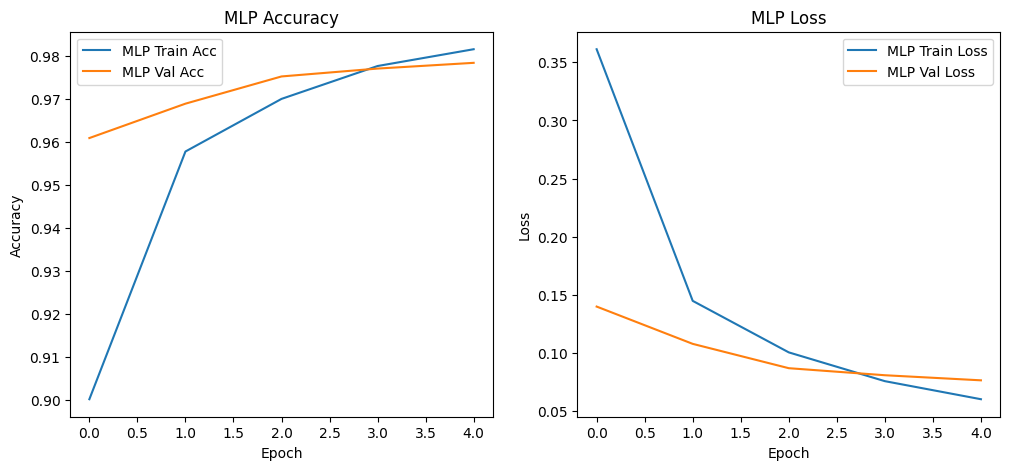

In [12]:
# Plot training history for MLP (accuracy over epochs and loss over epochs)
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(history_mlp.history['accuracy'], label='MLP Train Acc')
plt.plot(history_mlp.history['val_accuracy'], label='MLP Val Acc')
plt.title('MLP Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history_mlp.history['loss'], label='MLP Train Loss')
plt.plot(history_mlp.history['val_loss'], label='MLP Val Loss')
plt.title('MLP Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()


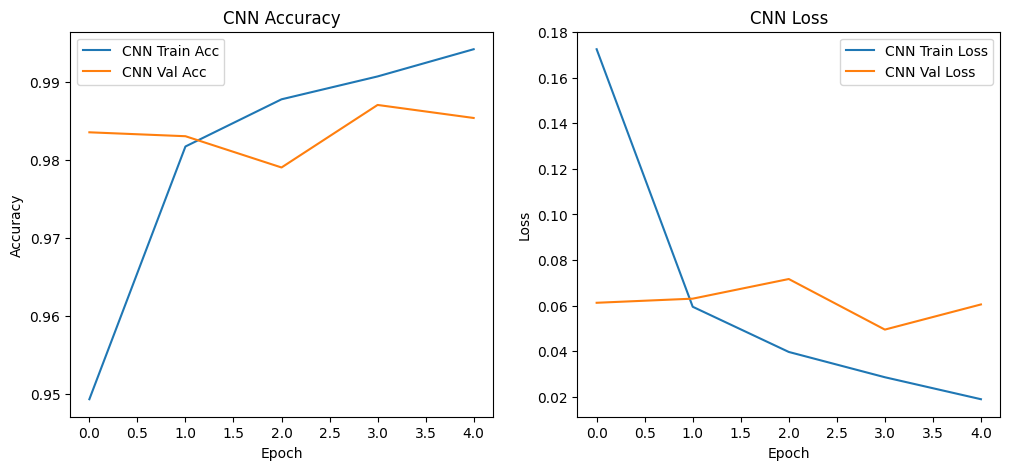

In [13]:
# plot training history for CNN (accuracy over epochs and loss over epochs)
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(cnn_history.history['accuracy'], label='CNN Train Acc')
plt.plot(cnn_history.history['val_accuracy'], label='CNN Val Acc')
plt.title('CNN Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(cnn_history.history['loss'], label='CNN Train Loss')
plt.plot(cnn_history.history['val_loss'], label='CNN Val Loss')
plt.title('CNN Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()

These visuals show that we are likely overfitting slightly. Probably should not add more epochs.

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 723us/step


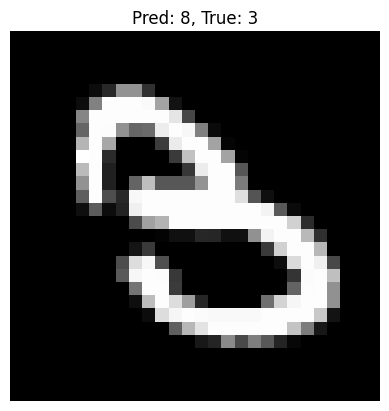

In [14]:
# Get predictions
cnn_predictions = cnn_model.predict(X_test_cnn)

# Find a misclassified example
for i in range(len(X_test)):
    pred = np.argmax(cnn_predictions[i])  # predicted class

    if pred != y_test[i]:                 # compare to true label
        plt.imshow(X_test[i], cmap="gray")
        plt.title(f"Pred: {pred}, True: {y_test[i]}")
        plt.axis("off")
        break

### How well do the models perform if we rotate the images?

Note: We did not train the model on these rotated images

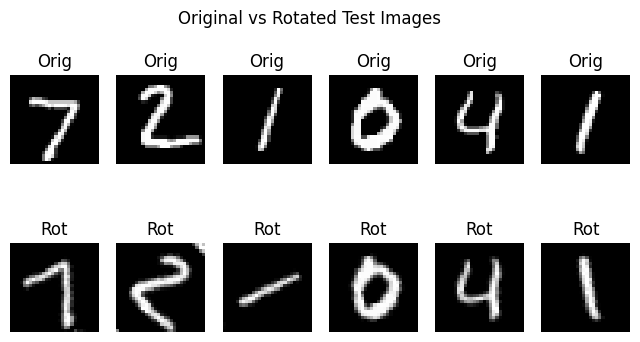

In [15]:
# Visualize rotated test images (to see what changed)

rotation_layer_eval = tf.keras.layers.RandomRotation(0.15)

X_test_rot_eval_cnn = rotation_layer_eval(X_test_cnn, training=True)

plt.figure(figsize=(8, 4))

for i in range(6):
    # Original
    plt.subplot(2, 6, i + 1)
    plt.imshow(X_test[i], cmap='gray')
    plt.title("Orig")
    plt.axis('off')

    # Rotated
    plt.subplot(2, 6, i + 7)
    plt.imshow(X_test_rot_eval_cnn[i].numpy().squeeze(), cmap='gray')
    plt.title("Rot")
    plt.axis('off')

plt.suptitle("Original vs Rotated Test Images")
plt.show()

In [16]:
# Flatten rotated images for MLP
X_test_rot_eval_flat = X_test_rot_eval_cnn.numpy().reshape(X_test.shape[0], -1)

# Evaluate original models on rotated data
mlp_rot_eval_loss, mlp_rot_eval_acc = mlp_model.evaluate(X_test_rot_eval_flat, y_test)
cnn_rot_eval_loss, cnn_rot_eval_acc = cnn_model.evaluate(X_test_rot_eval_cnn, y_test)

print("MLP accuracy (original test):", test_acc_mlp)
print("MLP accuracy (rotated test):", mlp_rot_eval_acc)

print("CNN accuracy (original test):", cnn_acc)
print("CNN accuracy (rotated test):", cnn_rot_eval_acc)

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 327us/step - accuracy: 0.7161 - loss: 1.4540
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 707us/step - accuracy: 0.7629 - loss: 1.2903
MLP accuracy (original test): 0.9732000231742859
MLP accuracy (rotated test): 0.7160999774932861
CNN accuracy (original test): 0.9836999773979187
CNN accuracy (rotated test): 0.7628999948501587


CNN better at recognizing rotated digits than MLP.

### New models trained with data augmentation (random rotations)

Now we add rotated images to train.

In [17]:
# Create rotated datasets for retraining models
rotation_layer_train = tf.keras.layers.RandomRotation(0.15)

X_train_rot_train_cnn = rotation_layer_train(X_train_cnn, training=True)  # rotated training images for CNN
X_test_rot_train_cnn = rotation_layer_train(X_test_cnn, training=True)    # rotated test images for CNN

# Flatten rotated datasets for MLP
X_train_rot_train_flat = X_train_rot_train_cnn.numpy().reshape(X_train.shape[0], -1)
X_test_rot_train_flat = X_test_rot_train_cnn.numpy().reshape(X_test.shape[0], -1)

### Use the code cell below to build, train and evaluate an MLP model using the rotated data (X_train_rot_train_flat and X_test_rot_train_flat)

In [ ]:
# Define the MLP model
mlp_model = keras.Sequential([
    layers.Input(shape=(784,)),                 # input is a flattened image (784 pixels)
    layers.Dense(128, activation="relu"),       # hidden layer with 128 neurons (learns patterns)
    layers.Dense(64, activation="relu"),        # second hidden layer for more complex patterns
    layers.Dense(32, activation = "relu"),      #third hidden layer (new)
    layers.Dense(10, activation="softmax"),     # output layer (10 classes for digits 0–9)
])

# Compile the MLP model
mlp_model.compile(
    optimizer="adam",                           # optimization algorithm for training
    loss="sparse_categorical_crossentropy",     # loss for multi-class classification with integer labels
    metrics=["accuracy"]                        # track accuracy during training
)

# summary of the MLP model architecture
mlp_model.summary()

Model: "sequential_4"
┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┳━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape  ┃ Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━╇━━━━━━━━━┩
│ dense_11 (Dense)    │ (None, 128)   │ 100,480 │
├─────────────────────┼───────────────┼─────────┤
│ dense_12 (Dense)    │ (None, 64)    │   8,256 │
├─────────────────────┼───────────────┼─────────┤
│ dense_13 (Dense)    │ (None, 32)    │   2,080 │
├─────────────────────┼───────────────┼─────────┤
│ dense_14 (Dense)    │ (None, 10)    │     330 │
└─────────────────────┴───────────────┴─────────┘
 Total params: 111,146 (434.16 KB)
 Trainable params: 111,146 (434.16 KB)
 Non-trainable params: 0 (0.00 B)


In [ ]:
# train the MLP model
history_mlp = mlp_model.fit(
    X_train_rot_train_flat,                               # rotated flattened training images
    y_train,                                    # labels (0–9)
    epochs=10,                                   # number of training passes through data (10 instead of 5)
    batch_size=64,                             # number of samples per training step (64 instead of 128)
    validation_split=0.1,                        # use 10% of training data for validation
    callbacks=[
        keras.callbacks.EarlyStopping(patience=3, restore_best_weights=True)  # stops if no improvement
    ]
)

# evaluate the MLP model on test data
test_loss_mlp, test_acc_mlp = mlp_model.evaluate(X_test_rot_train_flat, y_test, verbose=2)
print(f"MLP Test accuracy: {test_acc_mlp:.4f}")

Epoch 1/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 1s 870us/step - accuracy: 0.8393 - loss: 0.5232 - val_accuracy: 0.9278 - val_loss: 0.2444
Epoch 2/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 1s 720us/step - accuracy: 0.9252 - loss: 0.2435 - val_accuracy: 0.9455 - val_loss: 0.1810
Epoch 3/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 1s 773us/step - accuracy: 0.9448 - loss: 0.1785 - val_accuracy: 0.9513 - val_loss: 0.1674
Epoch 4/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 1s 708us/step - accuracy: 0.9541 - loss: 0.1460 - val_accuracy: 0.9565 - val_loss: 0.1489
Epoch 5/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 1s 733us/step - accuracy: 0.9617 - loss: 0.1193 - val_accuracy: 0.9555 - val_loss: 0.1481
Epoch 6/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 1s 739us/step - accuracy: 0.9679 - loss: 0.1002 - val_accuracy: 0.9588 - val_loss: 0.1458
Epoch 7/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 1s 737us/step - accuracy: 0.9712 - loss: 0.0876 - val_accuracy: 0.9617 - val_loss: 0.1392
Epoch 8/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 1s 736us/step - accuracy: 0.9755 - loss: 0.0738 - 

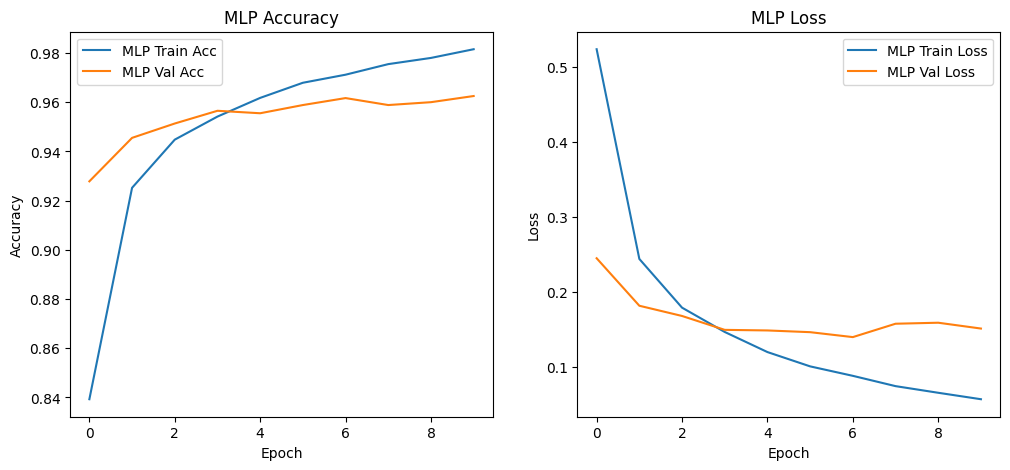

In [24]:
# Plot training history for MLP (accuracy over epochs and loss over epochs)
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(history_mlp.history['accuracy'], label='MLP Train Acc')
plt.plot(history_mlp.history['val_accuracy'], label='MLP Val Acc')
plt.title('MLP Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history_mlp.history['loss'], label='MLP Train Loss')
plt.plot(history_mlp.history['val_loss'], label='MLP Val Loss')
plt.title('MLP Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()

In [23]:
# Create rotated datasets for retraining models
rotation_layer_train = tf.keras.layers.RandomRotation(0.15)

X_train_rot_train_cnn = rotation_layer_train(X_train_cnn, training=True)  # rotated training images for CNN
X_test_rot_train_cnn = rotation_layer_train(X_test_cnn, training=True)    # rotated test images for CNN

# Flatten rotated datasets for MLP
X_train_rot_train_flat = X_train_rot_train_cnn.numpy().reshape(X_train.shape[0], -1)
X_test_rot_train_flat = X_test_rot_train_cnn.numpy().reshape(X_test.shape[0], -1)

### Use the code cell below to build, train and evaluate a CNN model using the rotated data (X_train_rot_train_cnn and X_test_rot_train_cnn)

In [25]:
# define the model

cnn_model = models.Sequential([
    layers.Input(shape=(28,28,1)),                 # input is 28x28 image with 1 channel (grayscale)
    layers.Conv2D(32, (3,3), activation="relu"),   # first conv: detect basic features (edges, curves)
    layers.MaxPooling2D((2,2)),                    # reduce spatial size
    layers.Conv2D(64, (3,3), activation="relu"),   # second conv: detect more complex features (new)
    layers.MaxPooling2D((2,2)),                    # reduce spatial size again (new)
    layers.Flatten(),                              # convert feature maps into a vector
    layers.Dense(64, activation="relu"),           # combine extracted features into higher-level patterns
    layers.Dense(10, activation="softmax"),        # output probabilities for digits 0–9
])

In [26]:
# compile the model
cnn_model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

# train the model
cnn_history = cnn_model.fit(
    X_train_rot_train_cnn,
    y_train,
    epochs=10,                                
    batch_size=64,                                
    validation_split=0.1,
    callbacks=[
        keras.callbacks.EarlyStopping(patience=3, restore_best_weights=True)  
    ]
)

Epoch 1/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 7s 7ms/step - accuracy: 0.8902 - loss: 0.3517 - val_accuracy: 0.9588 - val_loss: 0.1385
Epoch 2/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - accuracy: 0.9599 - loss: 0.1287 - val_accuracy: 0.9717 - val_loss: 0.0971
Epoch 3/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 6s 7ms/step - accuracy: 0.9719 - loss: 0.0893 - val_accuracy: 0.9768 - val_loss: 0.0780
Epoch 4/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 7s 8ms/step - accuracy: 0.9779 - loss: 0.0699 - val_accuracy: 0.9793 - val_loss: 0.0692
Epoch 5/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 7s 8ms/step - accuracy: 0.9835 - loss: 0.0540 - val_accuracy: 0.9750 - val_loss: 0.0842
Epoch 6/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 7s 8ms/step - accuracy: 0.9855 - loss: 0.0437 - val_accuracy: 0.9805 - val_loss: 0.0720
Epoch 7/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 7s 8ms/step - accuracy: 0.9883 - loss: 0.0363 - val_accuracy: 0.9835 - val_loss: 0.0658
Epoch 8/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 7s 8ms/step - accuracy: 0.9901 - loss: 0.0295 - val_accuracy: 0.

In [27]:
# Evaluate the CNN on test data
cnn_loss, cnn_acc = cnn_model.evaluate(X_test_cnn, y_test)  # evaluate on unseen test data
print("CNN Test Accuracy:", cnn_acc)                        # report final test accuracy

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9822 - loss: 0.0621
CNN Test Accuracy: 0.982200026512146


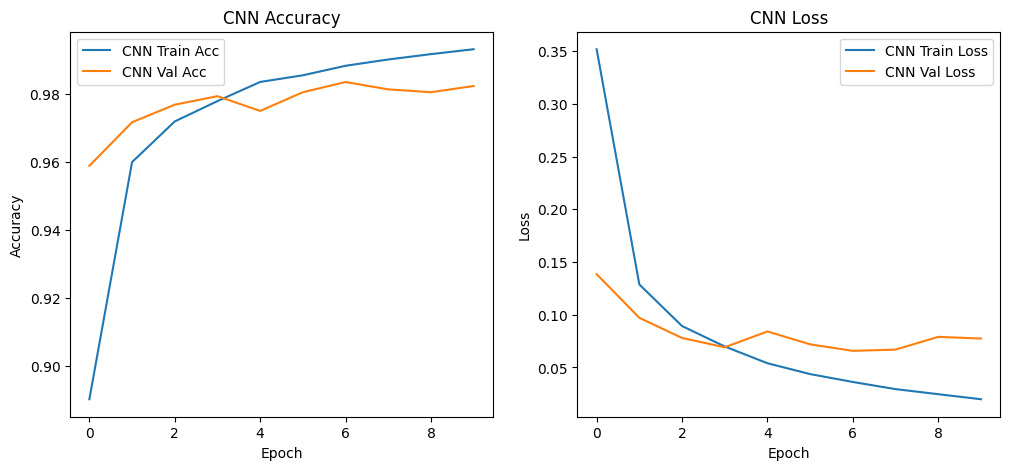

In [28]:
# plot training history for CNN (accuracy over epochs and loss over epochs)
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(cnn_history.history['accuracy'], label='CNN Train Acc')
plt.plot(cnn_history.history['val_accuracy'], label='CNN Val Acc')
plt.title('CNN Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(cnn_history.history['loss'], label='CNN Train Loss')
plt.plot(cnn_history.history['val_loss'], label='CNN Val Loss')
plt.title('CNN Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()

### Using the markdown cell below evaluate the performance of the MLP vs the CNN. Use graphs and metrics to support your evaluation.

For the MLP with the rotated images, I experimented with adding a third hidden layer, increasing the epochs from 5 to 10, and decreasing the batch size to 64. When evaluated with the test data, the MLP model had a test accuracy score of 0.9527. For the CNN with the rotated images, I added an additional convolution and pooling layer to detect more complex features. When evaluated with the test data, the CNN model had a test accuracy of 0.9822. So, the CNN model performed better compared to the MLP model in terms of test accuracy. However, both models performed substantially better than when the rotated images were not included in training (0.7160 and 0.7629 for the MLP and CNN models without the rotated images in training, respectively). Also, the experiment of increasing the complexity of the models as well as the epochs did not impact the validation accuracy or validation loss. For both the MLP and CNN models, the validation accuracy and loss doesn't increase much and flattens out over more epochs, likely due to overfitting.